Importing Liabraries

In [37]:
import numpy as np
import matplotlib.pyplot as plt 
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential       # type - ignore
from tensorflow.keras.layers import Dense            # type - ignore

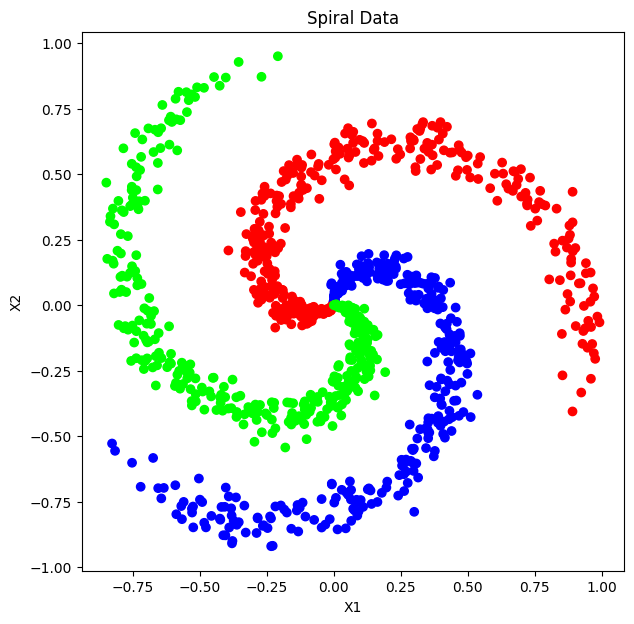

In [38]:
# Function to generate spiral data 
def generate_spiral_data(n_points, n_classes):
    X = []
    y = []
    for class_number in range(n_classes):
        ix = range(n_points * class_number, n_points * (class_number + 1))
        r = np.linspace(0.0, 1, n_points)       # Radius
        t = np.linspace(class_number * 4, (class_number + 1) * 4, n_points) + np.random.randn(n_points) * 0.2    # theta 
        X.extend(np.c_[r * np.sin(t), r * np.cos(t)])
        y.extend([class_number] * n_points)
    return np.array(X), np.array(y)

# Generate a spiral data 
X, y = generate_spiral_data(333, 3)         # 999 points , each for 333 (r,g,b)

# Plot the spiral data 
plt.figure(figsize=(7,7))
plt.scatter(X[:,0], X[:,1], c=y, cmap='brg')
plt.title('Spiral Data')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()


In [39]:
X 

array([[ 0.00000000e+00,  0.00000000e+00],
       [ 8.42243355e-05,  3.01087040e-03],
       [-1.47309193e-03,  5.84121027e-03],
       ...,
       [-3.55493153e-01,  9.28230960e-01],
       [-6.40331728e-01,  7.64172922e-01],
       [-5.80117052e-01,  8.14533122e-01]], shape=(999, 2))

In [40]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [41]:
# split the data into training and testing data sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  
# 20 % for testing & and 80 % for training data sets  

# Initialize the scalar 
scaler = StandardScaler()

# Fit the scaler on training data 
scaler.fit(X_train)

# Transform the training and testing data
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the model
model = Sequential()
model.add(Dense(64, input_dim=2, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(3, activation='softmax'))



c:\Users\sampa\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
X_train_scaled          
# X_train and X_train_scaled are different coz we have use mean and deviation  

array([[ 0.10726786, -0.76798487],
       [-0.6843326 , -1.96934886],
       [ 1.14428785, -0.35911652],
       ...,
       [-1.19110122, -0.71583136],
       [-0.47326615,  0.66384175],
       [ 0.75585061,  0.11816256]], shape=(799, 2))

In [43]:
# Compile the model 
# model.compile(optimizer = tf.keras.optimizer.SDG(), loss='sparse_categorial_crossentropy', metrics=['accuracy'])
model.compile(optimizer= "adam", loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [44]:
# Fit the model
history = model.fit(x=X_train_scaled, y=y_train,
                    validation_data=(X_test_scaled, y_test),
                    epochs=50, verbose=1)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5207 - loss: 0.9754 - val_accuracy: 0.5650 - val_loss: 0.8644
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5344 - loss: 0.8353 - val_accuracy: 0.5950 - val_loss: 0.7492
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5632 - loss: 0.7511 - val_accuracy: 0.6350 - val_loss: 0.6749
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5820 - loss: 0.6957 - val_accuracy: 0.6450 - val_loss: 0.6290
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6333 - loss: 0.6526 - val_accuracy: 0.6800 - val_loss: 0.5823
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6471 - loss: 0.6080 - val_accuracy: 0.7200 - val_loss: 0.5445
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7472 - loss: 0.5659 - val_accuracy: 0.7000 - val_loss: 0.5001
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7722 - loss: 0.5208 - val_accuracy: 0.8100 - val_loss

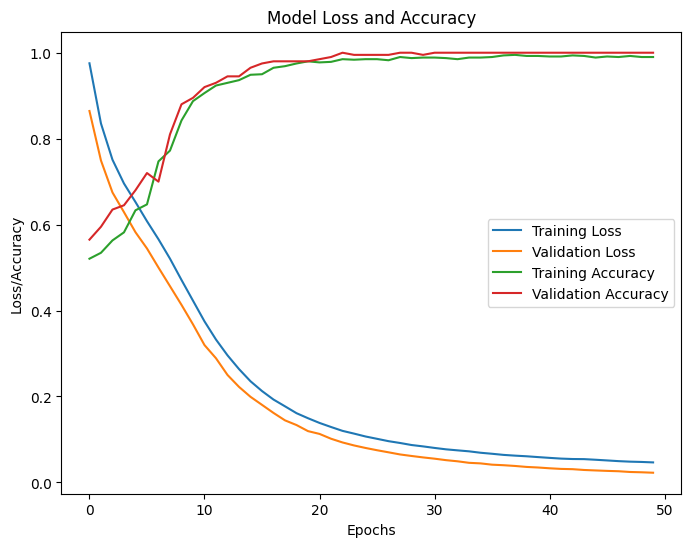

In [45]:
# Plot the training history
plt.figure(figsize=(8,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Loss and Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss/Accuracy')
plt.legend()
plt.show()


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


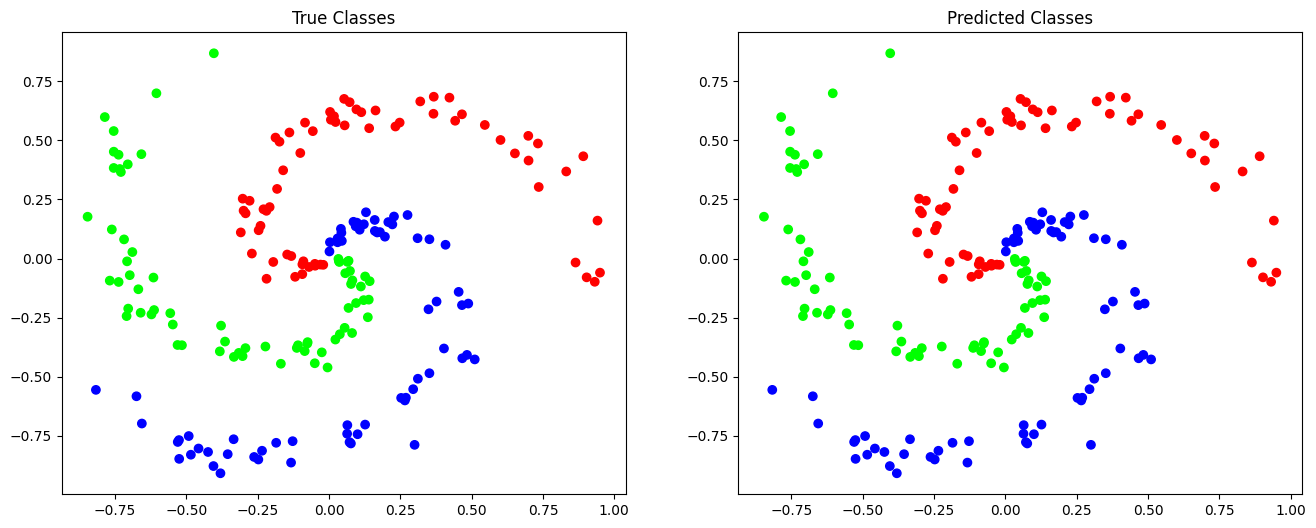

In [46]:
# Predicted the class for the test data 
y_pred = np.argmax(model.predict(X_test_scaled), axis=1)

# Plotting comaprison of predictions
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap='brg')
plt.title('True Classes')
plt.subplot(1, 2, 2)
plt.scatter(X_test[:,0], X_test[:,1], c=y_pred, cmap='brg')
plt.title('Predicted Classes')
plt.show()


 New test points 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


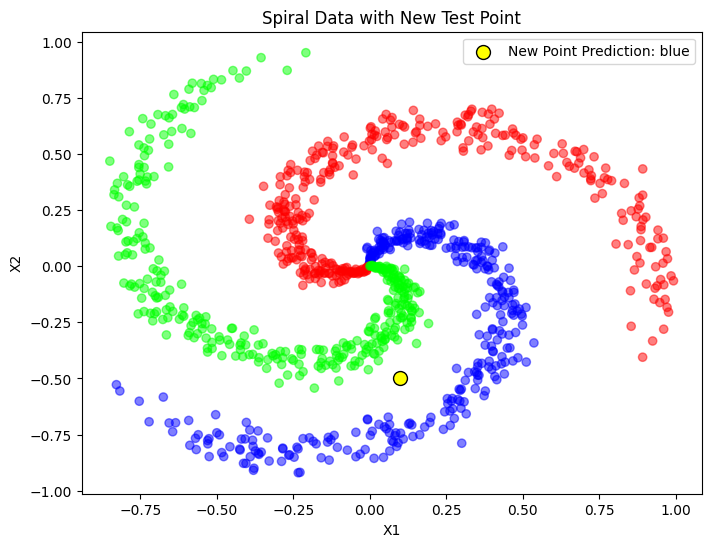

In [ ]:
new_point = np.array([[0.1, -0.5]])
new_point_scaled = scaler.transform(new_point)
new_pred = np.argmax(model.predict(new_point_scaled), axis=1)

# Color map for legend 
color_map = {0: 'red', 1: 'green', 2: 'blue'}

# Plot
plt.figure(figsize=(8,6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='brg', alpha=0.5)

plt.scatter(
    new_point[:, 0],
    new_point[:, 1],
    c='yellow',
    edgecolors='black',
    s=100,
    label=f'New Point Prediction: {color_map[new_pred[0]]}'
)

plt.title('Spiral Data with New Test Point')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.show()

